## Task: Predict number of bikers on a given day using linear regression

You are provided with a dataset about Seattle's Fremont Bridge in the form of a csv file.
The data contains different details about a given day, like weather, temperature and other factors (see the dataframe preview below) for more details. The data also contains how many bikers were observed crossing the brudge that day.

You are provided with the code to download and load the csv file.

Your task is to train a linear regression model which takes in the parameters of the day (you can drop the columns that you think you don't need) and predicts the number of bikers according to those parameters.

In [ ]:
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

In [ ]:
# Don't modify this code


%pip install gdown==4.5


clear_output()

In [ ]:
# Download the CSV file.
!gdown 1_eJU8Y-31_l0oq1sSJT6pROJyo-ufuvD

Downloading...
From: https://drive.google.com/uc?id=1_eJU8Y-31_l0oq1sSJT6pROJyo-ufuvD
To: /content/bikers_data.csv
100% 213k/213k [00:00<00:00, 102MB/s]


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data_df = pd.read_csv('bikers_data.csv')

In [ ]:
data_df.head()

,Date,Number of bikers,Mon,Tue,Wed,Thu,Fri,Sat,Sun,holiday,daylight_hrs,Rainfall (in),Temp (F),dry day
0,2012-10-03,14084.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11.277359,0.0,56.0,1
1,2012-10-04,13900.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,11.219142,0.0,56.5,1
2,2012-10-05,12592.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.161038,0.0,59.5,1
3,2012-10-06,8024.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,11.103056,0.0,60.5,1
4,2012-10-07,8568.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.045208,0.0,60.5,1


In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2646 non-null   object 
 1   Number of bikers  2646 non-null   float64
 2   Mon               2646 non-null   float64
 3   Tue               2646 non-null   float64
 4   Wed               2646 non-null   float64
 5   Thu               2646 non-null   float64
 6   Fri               2646 non-null   float64
 7   Sat               2646 non-null   float64
 8   Sun               2646 non-null   float64
 9   holiday           2646 non-null   float64
 10  daylight_hrs      2646 non-null   float64
 11  Rainfall (in)     2646 non-null   float64
 12  Temp (F)          2646 non-null   float64
 13  dry day           2646 non-null   int64  
dtypes: float64(12), int64(1), object(1)
memory usage: 289.5+ KB


In [ ]:
data_df.isnull().sum() #to see if there missing values

Date                0
Number of bikers    0
Mon                 0
Tue                 0
Wed                 0
Thu                 0
Fri                 0
Sat                 0
Sun                 0
holiday             0
daylight_hrs        0
Rainfall (in)       0
Temp (F)            0
dry day             0
dtype: int64

In [ ]:
data_df=data_df.drop('Date', axis=1) #drop the column date because it's not important

In [ ]:
data_df.info() #check the types of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Number of bikers  2646 non-null   float64
 1   Mon               2646 non-null   float64
 2   Tue               2646 non-null   float64
 3   Wed               2646 non-null   float64
 4   Thu               2646 non-null   float64
 5   Fri               2646 non-null   float64
 6   Sat               2646 non-null   float64
 7   Sun               2646 non-null   float64
 8   holiday           2646 non-null   float64
 9   daylight_hrs      2646 non-null   float64
 10  Rainfall (in)     2646 non-null   float64
 11  Temp (F)          2646 non-null   float64
 12  dry day           2646 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 268.9 KB


In [ ]:
data_y = data_df['Number of bikers'] # target
data_x = data_df.drop(['Number of bikers'], axis=1) # input features

In [ ]:
data_x.head()

,Mon,Tue,Wed,Thu,Fri,Sat,Sun,holiday,daylight_hrs,Rainfall (in),Temp (F),dry day
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11.277359,0.0,56.0,1
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,11.219142,0.0,56.5,1
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.161038,0.0,59.5,1
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,11.103056,0.0,60.5,1
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.045208,0.0,60.5,1


In [ ]:
data_y

0       14084.0
1       13900.0
2       12592.0
3        8024.0
4        8568.0
         ...   
2641     4552.0
2642     3352.0
2643     3692.0
2644     7212.0
2645     4568.0
Name: Number of bikers, Length: 2646, dtype: float64

In [ ]:
# Normalize input matrix so that data lies in the range of +1 to -1

X = (data_df - data_df.mean()) / (data_df.max() - data_df.min())

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, data_y, test_size = 0.2, random_state = 5)

In [ ]:
X_train.shape

(2116, 13)

In [ ]:
# n -> number of features, m -> number of samples
def initilize_parameters(n):
  w = np.random.rand(1, n)
  b = 0

  return w, b

In [ ]:
def forward(X, w, b): # w --> 1 x n, X --> m x n, the Linear_Regression equation

  z = np.dot(w, X) + b

  return z

In [ ]:
def cost_function(z, y): #Linear_Regression cost function
  m = y.shape[1]
  J = (1 / (2 * m) * np.sum(np.square(z - y)))

  return J

In [ ]:
def back_prop(X, y, z): #gradient descent of weights and bais
  m = y.shape[1]

  dz = (1 / m) * (z - y)

  dw = np.dot(dz, X.T)

  db = np.sum(dz)

  return dw, db

In [ ]:
def gradient_descent_update(w, b, dw, db, lr): #here we use the gradient_descent of w and b toupdate them accordingly to get best results

  w -=  lr * dw
  b -= lr * db

  return w, b

the codes under this its either to transpose them so we can multiplay them or convert them to np.array so we do not get error after

In [ ]:
print(f'{X_train.shape=}')
X_train = X_train.T
print(f'{X_train.shape=}')

X_train.shape=(2116, 13)
X_train.shape=(13, 2116)


In [ ]:
print(f'{y_train.shape=}')
y_train = np.array([y_train])
print(f'{y_train.shape=}')

y_train.shape=(2116,)
y_train.shape=(1, 2116)


In [ ]:
print(f'{X_test.shape=}')
X_test = X_test.T
print(f'{X_test.shape=}')

X_test.shape=(530, 13)
X_test.shape=(13, 530)


In [ ]:
print(f'{y_test.shape=}')
y_test = np.array([y_test])
print(f'{y_test.shape=}')

y_test.shape=(530,)
y_test.shape=(1, 530)


In [ ]:
def linear_regression_model(X_train, y_train, X_test, y_test, lr, epochs):

  n = X_train.shape[0] #number of the sample the same as the number of the feautres rows
  w, b = initilize_parameters(n) #give a random number for w and b, later they will be updated

  costs_train = [] #to gather all the cost of the train in one place so we can visulaize them
  m_train = y_train.shape[1]
  m_test = y_test.shape[1]

  # Training
  for i in range(epochs): #put number of epochs(how many times the mode will train) then call the methods we difined before

    y_pre = forward(X_train, w, b) #basic prediction
    cost_train = cost_function(y_pre, y_train)

    dw, db = back_prop(X_train, y_train, y_pre)
    w, b = gradient_descent_update(w, b, dw, db, lr)

    # store training cost in a list for plotting purpose
    if i % 10 == 0:
      costs_train.append(cost_train)


    # Testing
    # cost_test
    y_pre_test = forward(X_test, w, b)
    cost_test = cost_function(y_pre_test, y_test)


    # print cost_train, cost_val, MAE_train, MAE_val
    print(f'Epochs {i + 1} / {epochs}: ')
    print(f'Training cost {cost_train} | Testing cost {cost_test}')

  plt.plot(costs_train)
  plt.xlabel('Iterations(per tens)')
  plt.ylabel('Training cost')
  plt.title('Learning rate ' + str(lr))
  plt.show()


Epochs 1 / 500: 
Training cost 75657354.71101809 | Testing cost 33133295.013946712
Epochs 2 / 500: 
Training cost 34594625.24723238 | Testing cost 17814318.199761067
Epochs 3 / 500: 
Training cost 18769380.87690298 | Testing cost 11592234.245153053
Epochs 4 / 500: 
Training cost 12223226.534277763 | Testing cost 8751984.629282774
Epochs 5 / 500: 
Training cost 9172497.181214746 | Testing cost 7222888.529658302
Epochs 6 / 500: 
Training cost 7504322.083896053 | Testing cost 6246022.534428204
Epochs 7 / 500: 
Training cost 6433668.601819001 | Testing cost 5535650.853645553
Epochs 8 / 500: 
Training cost 5658567.30585109 | Testing cost 4977831.657993949
Epochs 9 / 500: 
Training cost 5054930.809259048 | Testing cost 4522035.632912476
Epochs 10 / 500: 
Training cost 4565845.010759774 | Testing cost 4142059.2022413937
Epochs 11 / 500: 
Training cost 4161049.7357625845 | Testing cost 3821798.033045483
Epochs 12 / 500: 
Training cost 3821830.479994388 | Testing cost 3549941.9617556646
Epochs 

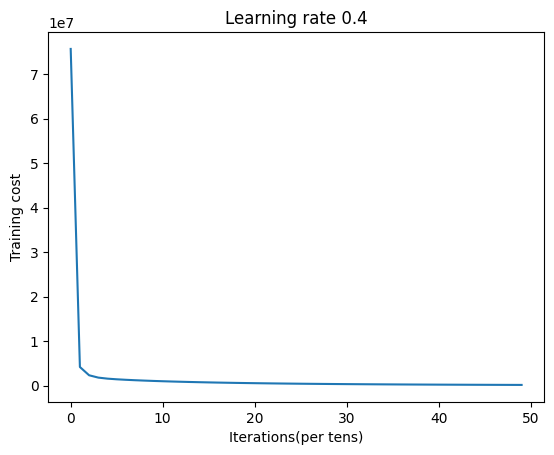

In [ ]:
linear_regression_model(X_train, y_train, X_test, y_test, 0.4, 500)